<a href="https://colab.research.google.com/github/kaynanxd/Teoria-Grafos/blob/main/ListaGrafosAc1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lista De grafos AC1 2026 - Kaynan Santos - Ana Beatriz

## Obs:Para Executar os arquivos de teste, clique no botao acima para abrir o projeto no google collab, primeiro se deve executar a classe referente a questao e em seguida o codigo de teste.

## Questao 1 :
Os turistas Janssen, Leuzinger, Alain e Medeiros se encontram em um bar de Paris e começam a
conversar. As línguas disponíveis são o inglês, o francês, o português e o alemão; Janssen fala todas
as línguas, Leuzinger não fala apenas português, Alain fala francês e alemão e Medeiros fala inglês e
português.:

##### A. Represente por meio de um grafo G(V,E) todas as possibilidades de um deles dirigir a palavra a outro, sendo compreendido. Defina V e E.


##### B. Se Leuzinger quer falar com Medeiros, qual seria a melhor forma de fazê-lo? (Represente isto num grafo G(V,E).


##### C. Qual a ordem e o tamanho de G(V,E)?

##### D. Qual a excentricidade de Alain? (Faz sentido isto?)

##### E. Qual o centro do grafo G(V,E)?

## Questao 2 :
Defina e dê um exemplo:

#### A. Três grafos isomorfos;


#### B. Construa um grafo de ordem 10, com sequência de graus (1, 1, 1, 3, 3, 3, 4, 6, 7, 9), ou mostre ser impossível construí-lo.



#### C. Mostre que nenhum grafo bipartido G(V1 V2, E) com V1  V2 é hamiltoniano.



#### D. Determine a cintura e a circunferência dos grafos associados a poliedros regulares.



#### E. Apresente dois grafos que não sejam nem simétricos nem anti-simétricos

## Questao 3 :
Verifique a definição se está correta e mostre um exemplo de grafo que a representa

#### a. Um circuito hamiltoniano contém um caminho elementar que passa por todos os vértices de umgrafo.


#### b. Um caminho euleriano só é possível de fazer em um grafo G(V,E) se ele contiver apenas doisvértices de grau par, ou todos os vértices tiverem grau ímpar.

#### c. Um grafo G(V,A) é simplesmente conexo (s-conexo) quando em todo par de vértices, ao menos um deles é atingível a partir do outro.

### d. Um grafo reduzido Gr(Vr,Lr), obtido de um grafo G(V,L) através de uma sequência decontrações de vértices, feitas segundo um critério pré-definido.

#### e. Um grafo linha Gl(Vl,Ll) de um grafo G(V,L) é um formado por um conjunto de vértices definidos pela contração de ligações de L, enquanto que as ligações de Ll representam os conjuntos de elos El e/ou de arcos Al das ligações adjacentes.


#### f. Uma ligação é dita adjacente a outra em um grafo G(V,L) se é possível fazer um caminho elementar direto entre pares de ligações (vo, vk) e (vk, vf) com um único vértice comum (k).


#### g. Um subconjunto de articulação em um grafo G(V,E) é um conjunto S de vértices cuja remoçãoresulta em um subgrafo não conexo de G, G’(WX, E’). Diz-se que S separa W de X ou que, em particular, separa todo vW de todo wX.

## Questao 4 :
Apresente um procedimento que resolva as seguintes situações, a partir de um grafo randômico
gerado G(V,E):

#### a. Dado um grafo G(V,E), ele é k-partido (k é dado)? Mostre as k-partições se houver.

#### b. Dado um grafo G(V,L), ele é simplesmente conexo?

####c. Ele é fortemente conexo?

#### d. Quantas componentes s-conexas possui? Mostre todas.


#### e. Quantas componentes f-conexas ele possui? Mostre todas.


#### f. Quantas cliques K5 e K6 tem um grafo G(V,E) dado?

#### g. Mostre o fecho transitivo de um vértice dado.

#### h. Mostre o fecho transitivo do grafo.

## Questao 5 :
Implemente uma classe multigrafo usando vetor de listas encadeadas simples, incluindo todas as
operações de edição (construir e destruir grafo, incluir, alterar, buscar, mostrar e remover) de vértices
e ligações. Considere que são admitidos atributos de custo e características do elemento vértice ou
ligação. Permita que seja gerado um grafo por entrada um a um dos dados, ou através de
preenchimento automático. Permita que sua implementação gere grafos distintos (2 pelo menos), de
modo que seja possível fazer comparações entre eles.

In [124]:

import random
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

class Aresta:
    def __init__(self, destino, custo=None, atributos=None):
        self.destino = destino
        self.custo = custo
        self.atributos = atributos or {}
    def __repr__(self):
        return f"(destino={self.destino}, custo={self.custo}, attr={self.atributos})"

class Vertice:
    def __init__(self, nome, atributos=None):
        self.nome = nome
        self.atributos = atributos or {}
    def __repr__(self):
        return f"Vertice({self.nome}, attr={self.atributos})"

class MultiGrafo:
    def __init__(self, nome="Grafo", direcionado=True):
        self.nome = nome
        self.vertices = {}
        self.adj = {}
        self.direcionado = direcionado

    def adicionar_vertice(self, nome, atributos=None):
        if nome not in self.vertices:
            self.vertices[nome] = Vertice(nome, atributos)
            self.adj[nome] = []
        else:
            print(f"Vértice {nome} já existe.")

    def adicionar_aresta(self, origem, destino, custo=None, atributos=None):
        if origem not in self.vertices or destino not in self.vertices:
            print("Erro: vértices inexistentes.")
            return

        aresta = Aresta(destino, custo, atributos)
        self.adj[origem].append(aresta)

        if not self.direcionado:
            aresta_volta = Aresta(origem, custo, atributos)
            self.adj[destino].append(aresta_volta)

    def alterar_vertice(self, nome, novos_atributos):
        if nome in self.vertices:
            self.vertices[nome].atributos.update(novos_atributos)

    def alterar_aresta(self, origem, destino, novo_custo=None):
        if origem in self.adj:
            for aresta in self.adj[origem]:
                if aresta.destino == destino:
                    if novo_custo is not None:
                        aresta.custo = novo_custo

    def buscar_vertice(self, nome):
        return self.vertices.get(nome, None)

    def buscar_arestas(self, origem):
        return self.adj.get(origem, [])

    def remover_vertice(self, nome):
        if nome in self.vertices:
            del self.vertices[nome]
            del self.adj[nome]

            for v in self.adj:
                self.adj[v] = [a for a in self.adj[v] if a.destino != nome]

    def remover_aresta(self, origem, destino):
        if origem in self.adj:
            self.adj[origem] = [
                a for a in self.adj[origem] if a.destino != destino
            ]

    def mostrar(self):
        print(f"\n--- {self.nome} ---")
        for v in self.adj:
            vertice = self.vertices[v]
            print(f"{v} {vertice.atributos} -> {self.adj[v]}")

    def destruir(self):
        self.vertices.clear()
        self.adj.clear()

    def get_vertices(self):
        return list(self.vertices.keys())

    def get_arestas(self):
        arestas = []
        for v in self.adj:
            for a in self.adj[v]:
                arestas.append((v, a.destino, a.custo))
        return arestas
    #----def para desenhar os graficos na saidaa---
    def visualizar(self):
        G = nx.MultiDiGraph() if self.direcionado else nx.MultiGraph()

        for v in self.vertices:
            G.add_node(v)

        arestas_adicionadas = set()

        for origem in self.adj:
            for aresta in self.adj[origem]:
                u, v = origem, aresta.destino

                if not self.direcionado:
                    edge_key = tuple(sorted([u, v]))
                    if edge_key in arestas_adicionadas:
                        continue
                    arestas_adicionadas.add(edge_key)
                else:
                    edge_key = (u, v, id(aresta))

                if aresta.custo is not None:
                    G.add_edge(u, v, weight=aresta.custo)
                else:
                    G.add_edge(u, v)

        # desenhar nós
        pos = nx.spring_layout(G, k=0.3, seed=42)
        node_colors = []

        for v in G.nodes():
            vertice = self.vertices[v]
            cor = vertice.atributos.get("cor", "lightblue")
            node_colors.append(cor)
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors)
        nx.draw_networkx_labels(G, pos)

        edge_groups = defaultdict(list)

        for (u, v, k) in G.edges(keys=True):
            edge_groups[(u, v)].append((u, v, k))

        #desenha as arestas se for 1 e reto se for 2 curvo
        for (u, v), edges in edge_groups.items():
            n = len(edges)

            for i, (u, v, k) in enumerate(edges):
                if n == 1:
                    rad = 0
                else:
                    rad = (i - (n - 1) / 2) * 0.3

                nx.draw_networkx_edges(
                    G, pos,
                    edgelist=[(u, v)],
                    connectionstyle=f"arc3,rad={rad}",
                    arrows=True,
                    min_source_margin=15,
                    min_target_margin=15
                )

        #pesos (se existirem)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        plt.title(self.nome)
        plt.show()

def gerar_grafo_aleatorio(grafo, n_vertices, n_arestas):
    for i in range(n_vertices):
        grafo.adicionar_vertice(f"V{i}")

    vertices = grafo.get_vertices()

    for _ in range(n_arestas):
        v1 = random.choice(vertices)
        v2 = random.choice(vertices)
        custo = random.randint(1, 10)
        grafo.adicionar_aresta(v1, v2, custo)



[Estado inicial do Grafo 1]

--- Grafo 1 ---
A {} -> [(destino=B, custo=None, attr={})]
B {} -> [(destino=A, custo=None, attr={}), (destino=C, custo=None, attr={})]
C {} -> []


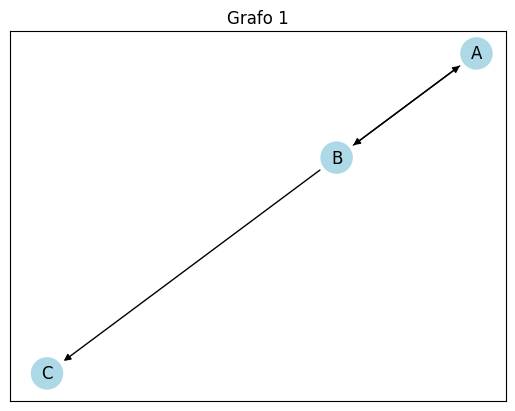


[Após alterações da cor de A]

--- Grafo 1 ---
A {'cor': 'red'} -> [(destino=B, custo=None, attr={})]
B {} -> [(destino=A, custo=None, attr={}), (destino=C, custo=None, attr={})]
C {} -> []


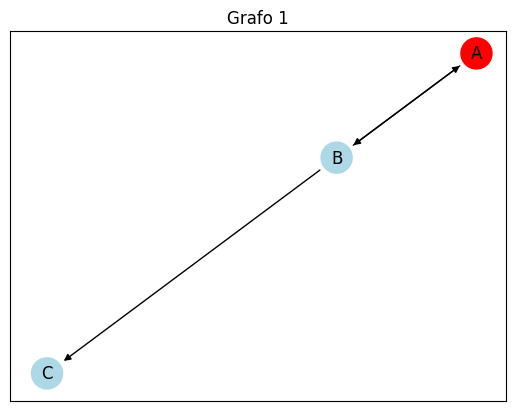


[Buscas]
Buscar vértice A:
 Vertice(A, attr={'cor': 'red'})
Arestas de A:
 [(destino=B, custo=None, attr={})]

[Após remover C]

--- Grafo 1 ---
A {'cor': 'red'} -> [(destino=B, custo=None, attr={})]
B {} -> [(destino=A, custo=None, attr={})]


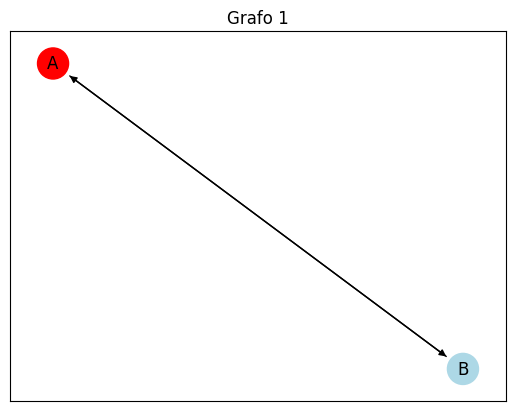


[Grafo 2 - automático]

--- Grafo 2 ---
V0 {} -> [(destino=V1, custo=1, attr={}), (destino=V2, custo=7, attr={})]
V1 {} -> []
V2 {} -> [(destino=V2, custo=6, attr={})]


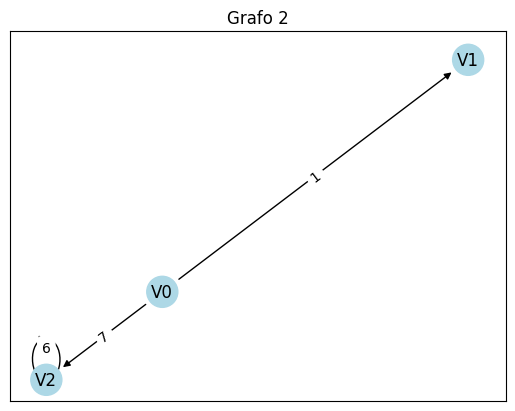

In [126]:
#Teste da classe multigrafo

g1 = MultiGrafo("Grafo 1", direcionado=True)

g1.adicionar_vertice("A")
g1.adicionar_vertice("B")
g1.adicionar_vertice("C")

g1.adicionar_aresta("A", "B")
g1.adicionar_aresta("B", "A")
g1.adicionar_aresta("B", "C")

print("\n[Estado inicial do Grafo 1]")
g1.mostrar()
g1.visualizar()

#Alteração
g1.alterar_vertice("A", {"cor": "red"})

print("\n[Após alterações da cor de A]")
g1.mostrar()
g1.visualizar()

# Busca
print("\n[Buscas]")
print("Buscar vértice A:\n", g1.buscar_vertice("A"))
print("Arestas de A:\n", g1.buscar_arestas("A"))

# Remoção
g1.remover_vertice("C")

print("\n[Após remover C]")
g1.mostrar()
g1.visualizar()

# grafo gerado aleatoriamente
g2 = MultiGrafo("Grafo 2", direcionado=True)
gerar_grafo_aleatorio(g2, 3, 3)

print("\n[Grafo 2 - automático]")
g2.mostrar()
g2.visualizar()

## Questao 6 :
Utilizando a estrutura de dados mais adequada, implemente um algoritmo de travessia (in-order) do
grafo formado e apresente no seu grafo implementado da questão 5, o resultado da rotulação
topológica encontrada.

# Questao 7 :
Utilizando a estrutura de dados mais adequada, implemente um algoritmo de travessia (pos-order) e
apresente no seu grafo implementado da questão 5, o resultado da rotulação topológica encontrada.

# Questao 8 :
Utilizando a estrutura mais adequada, apresente uma solução onde se produz um subgrafo maximal
árvore em G.

# Questao 9 :
Dados dois grafos G1 e G2, verifique se são isomorfos.

# Questao 10 :
Dados dois grafos G1 e G2, verifique sua similaridade pelos métodos de Jaccarta, Cosseno e
Coeficiente de Sobreposição.

# Questao 11 :
Verifique os seguintes valores no grafo G(V,E) dado: Cintura e Circunferência de G.

# Questao 12 :
Verifique os seguintes valores no grafo G(V,E) dado: Excentricidade de v dado.

# Questao 13 :
Verifique os seguintes valores no grafo G(V,E) dado: Raio, Diâmetro e Centro de G.

# Questao 14 :
Verifique e apresente no grafo G(V,E) dado: Corte em vértices e arestas de G.

# Questao 15 :
Verifique e apresente no grafo G(V,E) dado: Corte Fundamental de G.

# Questao 16 :
Verifique se G(V,E) é planar.

# Questao 17 :
Utilizando a estrutura de dados mais adequada, implemente um algoritmo de travessia (DFS) do
grafo formado e apresente no seu grafo implementado da questão 5, o resultado da rotulação
topológica encontrada.

# Questao 18 :
Utilizando a estrutura de dados mais adequada, implemente um algoritmo de travessia (BFS) e
apresente no seu grafo implementado da questão 5, o resultado da rotulação topológica encontrada.